# SmartSort: Waste Classification with PyTorch

Baseline experiment for classifying household waste into ten categories. Only the
original images are used; the 256 px and 384 px folders are resized copies and would
leak the same images across data splits.

## Approach

1. Check image integrity and remove exact duplicates.
2. Create fixed, stratified train/validation/test splits.
3. Train a custom CNN or fine-tune ResNet18.
4. Compare models with macro-F1 and inspect their mistakes.

### Dataset assumptions

1. Folder names are the ground-truth labels.
2. Only one copy of an exact duplicate is retained.
3. The Kaggle dataset's resized variants are transformations of the originals, not
   independent observations.
4. Macro-F1 is the primary model-selection metric because the class distribution is
   imbalanced.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import random
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the SmartSort project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "original"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
QUICK_RUN = True
QUICK_TRAIN_SAMPLES = 2_500
QUICK_EVAL_SAMPLES = 600
MODEL_NAME = "custom_cnn"  # "custom_cnn" or "resnet18"
USE_PRETRAINED_WEIGHTS = False
EPOCHS = 2 if QUICK_RUN else 15
LEARNING_RATE = 1e-3 if MODEL_NAME == "custom_cnn" else 3e-4
WEIGHT_DECAY = 1e-4


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


seed_everything()
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Project: {PROJECT_ROOT.name}")
print(f"PyTorch: {torch.__version__} | device: {DEVICE}")
print(f"Run: {'quick' if QUICK_RUN else 'full'}")

Project: SmartSort
PyTorch: 2.13.0 | device: mps
Run: quick


## Data

### 1. Inventory and integrity audit

Each image is opened with Pillow and hashed with SHA-256. Files that fail validation
are excluded before data loading.

In [2]:
assert DATA_DIR.exists(), (
    f"Dataset not found at {DATA_DIR}. Run: kaggle datasets download "
    "-d sumn2u/garbage-classification-v2 -p data/raw --unzip"
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
image_paths = sorted(
    path for path in DATA_DIR.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)


def audit_image(path: Path) -> dict:
    record = {
        "path": str(path.resolve()),
        "relative_path": str(path.relative_to(DATA_DIR)),
        "label": path.parent.name,
        "valid": False,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "sha256": None,
        "error": None,
    }
    try:
        file_bytes = path.read_bytes()
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            record.update(
                valid=True,
                width=image.width,
                height=image.height,
                mode=image.mode,
                sha256=hashlib.sha256(file_bytes).hexdigest(),
            )
    except (OSError, UnidentifiedImageError, ValueError) as exc:
        record["error"] = f"{type(exc).__name__}: {exc}"
    return record


audit_cache = PROCESSED_DIR / "image_audit.csv"
if audit_cache.exists():
    audit_df = pd.read_csv(audit_cache)
    cached_paths = set(audit_df["path"])
    current_paths = {str(path.resolve()) for path in image_paths}
    if cached_paths != current_paths:
        audit_df = pd.DataFrame([audit_image(path) for path in tqdm(image_paths, desc="Auditing")])
        audit_df.to_csv(audit_cache, index=False)
else:
    audit_df = pd.DataFrame([audit_image(path) for path in tqdm(image_paths, desc="Auditing")])
    audit_df.to_csv(audit_cache, index=False)

audit_summary = pd.Series(
    {
        "files_discovered": len(audit_df),
        "valid_images": int(audit_df["valid"].sum()),
        "corrupt_images": int((~audit_df["valid"]).sum()),
        "classes": audit_df.loc[audit_df["valid"], "label"].nunique(),
        "exact_duplicate_files": int(
            audit_df.loc[audit_df["valid"], "sha256"].duplicated(keep="first").sum()
        ),
    }
)
audit_summary.to_frame("count")

,count
files_discovered,12259
valid_images,12259
corrupt_images,0
classes,10
exact_duplicate_files,0


In [3]:
invalid_df = audit_df.loc[~audit_df["valid"], ["relative_path", "error"]]
if len(invalid_df):
    display(invalid_df.head(20))
else:
    print("No corrupt images detected.")

valid_df = audit_df.loc[audit_df["valid"]].copy()
hash_label_counts = valid_df.groupby("sha256")["label"].nunique()
conflicting_hashes = hash_label_counts[hash_label_counts > 1]
assert conflicting_hashes.empty, "Identical image bytes appear under conflicting labels."

duplicate_count = int(valid_df.duplicated("sha256", keep="first").sum())
clean_df = valid_df.drop_duplicates("sha256", keep="first").reset_index(drop=True)
print(f"Retained {len(clean_df):,} unique valid images; removed {duplicate_count:,} exact duplicates.")

No corrupt images detected.
Retained 12,259 unique valid images; removed 0 exact duplicates.


### 2. Class distribution and image characteristics

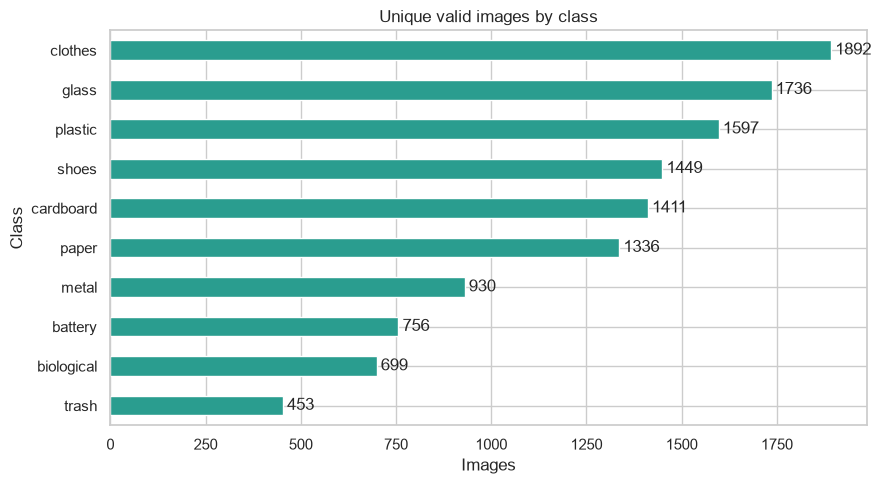

,images
label,
battery,756
biological,699
cardboard,1411
clothes,1892
glass,1736
metal,930
paper,1336
plastic,1597
shoes,1449


In [4]:
class_counts = clean_df["label"].value_counts().sort_values(ascending=True)
ax = class_counts.plot.barh(figsize=(9, 5), color="#2a9d8f")
ax.set(title="Unique valid images by class", xlabel="Images", ylabel="Class")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()

display(class_counts.sort_index().rename("images").to_frame())

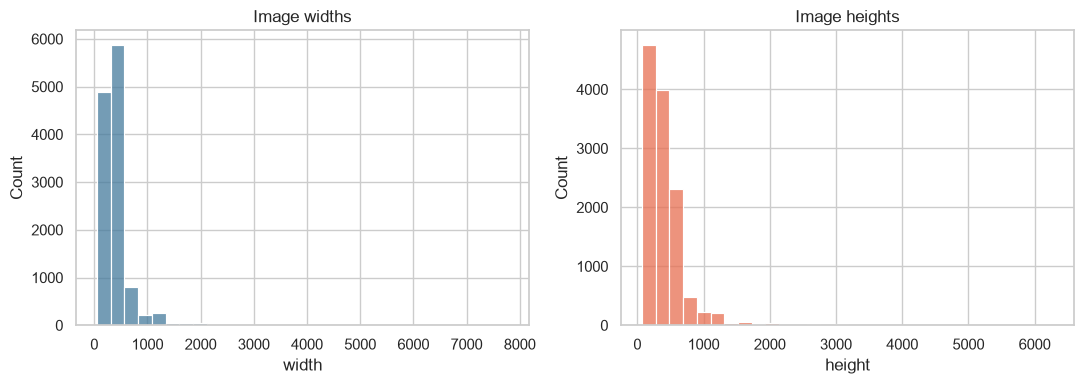

,width,height
count,12259.0,12259.0
mean,440.1,430.6
std,329.6,361.8
min,51.0,71.0
25%,252.0,225.0
50%,400.0,384.0
75%,512.0,533.0
max,7786.0,6283.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(clean_df["width"], bins=30, ax=axes[0], color="#457b9d")
axes[0].set_title("Image widths")
sns.histplot(clean_df["height"], bins=30, ax=axes[1], color="#e76f51")
axes[1].set_title("Image heights")
plt.tight_layout()
plt.show()

display(clean_df[["width", "height"]].describe().round(1))

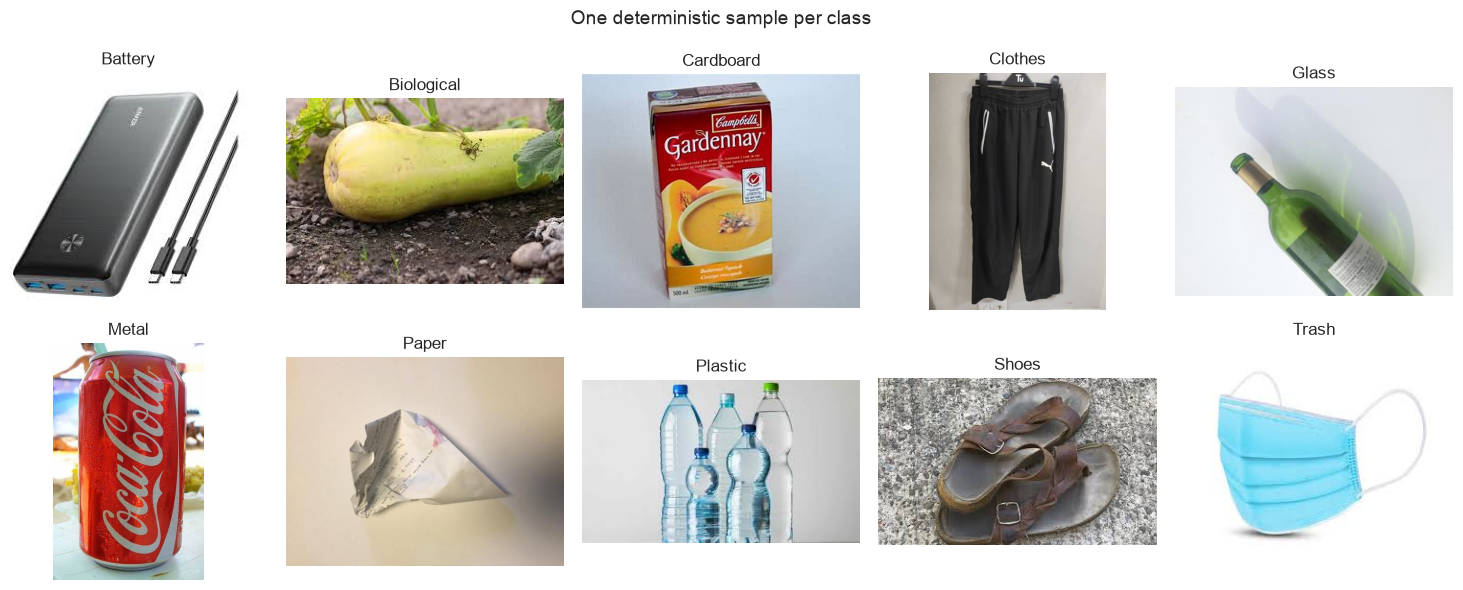

In [6]:
classes = sorted(clean_df["label"].unique())
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for axis, label in zip(axes.flat, classes):
    sample_path = Path(clean_df.loc[clean_df["label"] == label, "path"].sample(1, random_state=SEED).iloc[0])
    with Image.open(sample_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(label.title())
    axis.axis("off")
plt.suptitle("One deterministic sample per class", fontsize=14)
plt.tight_layout()
plt.show()

### 3. Leakage-safe stratified splits

The test set is isolated first. The remaining data is split into train and validation
sets. Exact duplicates were removed before splitting, so the same bytes cannot appear
in more than one partition.

In [7]:
train_df, holdout_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=SEED,
    stratify=clean_df["label"],
)
val_df, test_df = train_test_split(
    holdout_df,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout_df["label"],
)

split_frames = []
for split_name, frame in (("train", train_df), ("validation", val_df), ("test", test_df)):
    frame = frame.copy()
    frame["split"] = split_name
    split_frames.append(frame)

manifest_df = pd.concat(split_frames, ignore_index=True)
manifest_df.to_csv(PROCESSED_DIR / "splits.csv", index=False)

assert manifest_df["sha256"].nunique() == len(manifest_df)
assert set(train_df["sha256"]).isdisjoint(val_df["sha256"])
assert set(train_df["sha256"]).isdisjoint(test_df["sha256"])
assert set(val_df["sha256"]).isdisjoint(test_df["sha256"])

split_table = pd.crosstab(manifest_df["label"], manifest_df["split"])
split_table.loc["TOTAL"] = split_table.sum()
display(split_table)

split,test,train,validation
label,,,
battery,113,529,114
biological,105,489,105
cardboard,211,988,212
clothes,284,1325,283
glass,261,1215,260
metal,140,651,139
paper,200,935,201
plastic,240,1118,239
shoes,217,1014,218


### 4. PyTorch input pipeline

In [8]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(12),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

class_names = sorted(clean_df["label"].unique())
class_to_idx = {label: index for index, label in enumerate(class_names)}


class WasteDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        with Image.open(row["path"]) as image:
            image = image.convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, class_to_idx[row["label"]], row["path"]


def stratified_sample(frame: pd.DataFrame, max_samples: int, seed: int) -> pd.DataFrame:
    if len(frame) <= max_samples:
        return frame.copy()
    sample, _ = train_test_split(
        frame,
        train_size=max_samples,
        random_state=seed,
        stratify=frame["label"],
    )
    return sample.reset_index(drop=True)


loader_train_df = stratified_sample(train_df, QUICK_TRAIN_SAMPLES, SEED) if QUICK_RUN else train_df
loader_val_df = stratified_sample(val_df, QUICK_EVAL_SAMPLES, SEED) if QUICK_RUN else val_df
loader_test_df = stratified_sample(test_df, QUICK_EVAL_SAMPLES, SEED) if QUICK_RUN else test_df

train_dataset = WasteDataset(loader_train_df, train_transform)
val_dataset = WasteDataset(loader_val_df, eval_transform)
test_dataset = WasteDataset(loader_test_df, eval_transform)

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    generator=generator,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch_images, batch_targets, _ = next(iter(train_loader))
print("Batch tensor:", tuple(batch_images.shape))
print("Target tensor:", tuple(batch_targets.shape))
print("Loader sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

Batch tensor: (32, 3, 224, 224)
Target tensor: (32,)
Loader sizes: 2500 600 600


## Models

The custom CNN is the baseline. ResNet18 is included for transfer learning.

In [9]:
class ConvBlock(nn.Sequential):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )


class CustomCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, 0.05),
            ConvBlock(32, 64, 0.10),
            ConvBlock(64, 128, 0.15),
            ConvBlock(128, 256, 0.20),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(inputs))


def build_resnet18(num_classes: int, pretrained: bool = True) -> nn.Module:
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.30), nn.Linear(in_features, num_classes))
    return model


def build_model(name: str) -> nn.Module:
    if name == "custom_cnn":
        return CustomCNN(len(class_names))
    if name == "resnet18":
        return build_resnet18(len(class_names), pretrained=USE_PRETRAINED_WEIGHTS)
    raise ValueError(f"Unknown model: {name}")


model = build_model(MODEL_NAME).to(DEVICE)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"{MODEL_NAME}: {trainable_parameters:,} trainable parameters")

with torch.inference_mode():
    smoke_logits = model(batch_images[:2].to(DEVICE))
assert smoke_logits.shape == (2, len(class_names))
print("Forward-pass check:", tuple(smoke_logits.shape))

custom_cnn: 1,175,786 trainable parameters


Forward-pass check: (2, 10)


## Training

Weighted cross-entropy accounts for class imbalance. The best validation macro-F1
checkpoint is retained.

In [10]:
train_counts = train_df["label"].value_counts()
class_weights = torch.tensor(
    [len(train_df) / (len(class_names) * train_counts[label]) for label in class_names],
    dtype=torch.float32,
    device=DEVICE,
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


def compute_metrics(targets: list[int], predictions: list[int]) -> dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, predictions, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(targets, predictions),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


def run_epoch(model, loader, criterion, optimizer=None) -> dict[str, float]:
    training = optimizer is not None
    model.train(training)
    running_loss = 0.0
    all_targets, all_predictions = [], []

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for images, targets, _ in tqdm(loader, leave=False, desc="train" if training else "evaluate"):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().tolist())
            all_predictions.extend(logits.argmax(dim=1).detach().cpu().tolist())

    metrics = compute_metrics(all_targets, all_predictions)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics


def train_model(model, train_loader, val_loader, epochs: int, patience: int = 4) -> pd.DataFrame:
    history = []
    best_f1 = -np.inf
    epochs_without_improvement = 0
    checkpoint_path = MODEL_DIR / f"{MODEL_NAME}_best.pt"

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        train_metrics = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics = run_epoch(model, val_loader, criterion)
        scheduler.step(val_metrics["macro_f1"])

        row = {
            "epoch": epoch,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
            "learning_rate": optimizer.param_groups[0]["lr"],
            "seconds": time.perf_counter() - started,
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d}/{epochs} | train loss {train_metrics['loss']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | val macro-F1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_name": MODEL_NAME,
                    "model_state_dict": model.state_dict(),
                    "class_names": class_names,
                    "image_size": IMAGE_SIZE,
                    "best_val_macro_f1": best_f1,
                    "epoch": epoch,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch}.")
                break

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    return pd.DataFrame(history)


history_df = train_model(model, train_loader, val_loader, EPOCHS)
history_df.to_csv(PROCESSED_DIR / f"{MODEL_NAME}_history.csv", index=False)
display(history_df.round(4))

train:   0%|          | 0/79 [00:00<?, ?it/s]

evaluate:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01/2 | train loss 2.1696 | val loss 1.9622 | val macro-F1 0.2702


train:   0%|          | 0/79 [00:00<?, ?it/s]

evaluate:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 02/2 | train loss 2.0563 | val loss 2.0033 | val macro-F1 0.2439


,epoch,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_loss,learning_rate,seconds
0,1,0.2068,0.1886,0.2191,0.1861,2.1696,0.3167,0.2584,0.3312,0.2702,1.9622,0.001,35.9237
1,2,0.2464,0.2271,0.2605,0.2298,2.0563,0.3000,0.2581,0.3111,0.2439,2.0033,0.001,36.2507


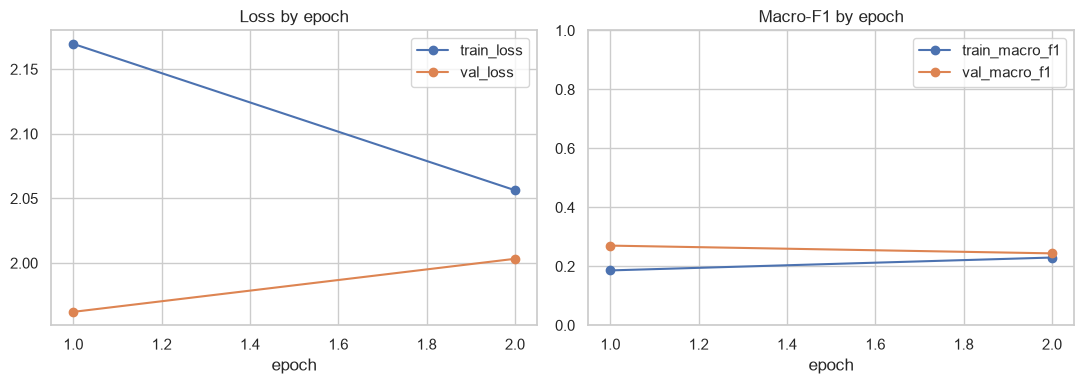

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_df.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", ax=axes[0])
axes[0].set_title("Loss by epoch")
history_df.plot(x="epoch", y=["train_macro_f1", "val_macro_f1"], marker="o", ax=axes[1])
axes[1].set_title("Macro-F1 by epoch")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Results

The test split is evaluated once, after selecting the checkpoint on validation data.

In [12]:
def collect_predictions(model, loader) -> pd.DataFrame:
    model.eval()
    rows = []
    with torch.inference_mode():
        for images, targets, paths in tqdm(loader, leave=False, desc="test predictions"):
            probabilities = model(images.to(DEVICE)).softmax(dim=1).cpu()
            confidences, predictions = probabilities.max(dim=1)
            for path, target, prediction, confidence in zip(
                paths, targets.tolist(), predictions.tolist(), confidences.tolist()
            ):
                rows.append(
                    {
                        "path": path,
                        "target_idx": target,
                        "prediction_idx": prediction,
                        "target": class_names[target],
                        "prediction": class_names[prediction],
                        "confidence": confidence,
                        "correct": target == prediction,
                    }
                )
    return pd.DataFrame(rows)


predictions_df = collect_predictions(model, test_loader)
test_metrics = compute_metrics(
    predictions_df["target_idx"].tolist(), predictions_df["prediction_idx"].tolist()
)
display(pd.Series(test_metrics, name="test").to_frame().round(4))

report_df = pd.DataFrame(
    classification_report(
        predictions_df["target"],
        predictions_df["prediction"],
        labels=class_names,
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df.round(3))

test predictions:   0%|          | 0/19 [00:00<?, ?it/s]

,test
accuracy,0.2817
macro_precision,0.2291
macro_recall,0.2903
macro_f1,0.2287


,precision,recall,f1-score,support
battery,0.216,0.595,0.317,37.000
biological,0.303,0.676,0.418,34.000
cardboard,0.440,0.319,0.370,69.000
clothes,0.356,0.344,0.350,93.000
glass,0.250,0.012,0.022,85.000
metal,0.000,0.000,0.000,46.000
paper,0.261,0.369,0.306,65.000
plastic,0.293,0.462,0.358,78.000
shoes,0.173,0.127,0.146,71.000
trash,0.000,0.000,0.000,22.000


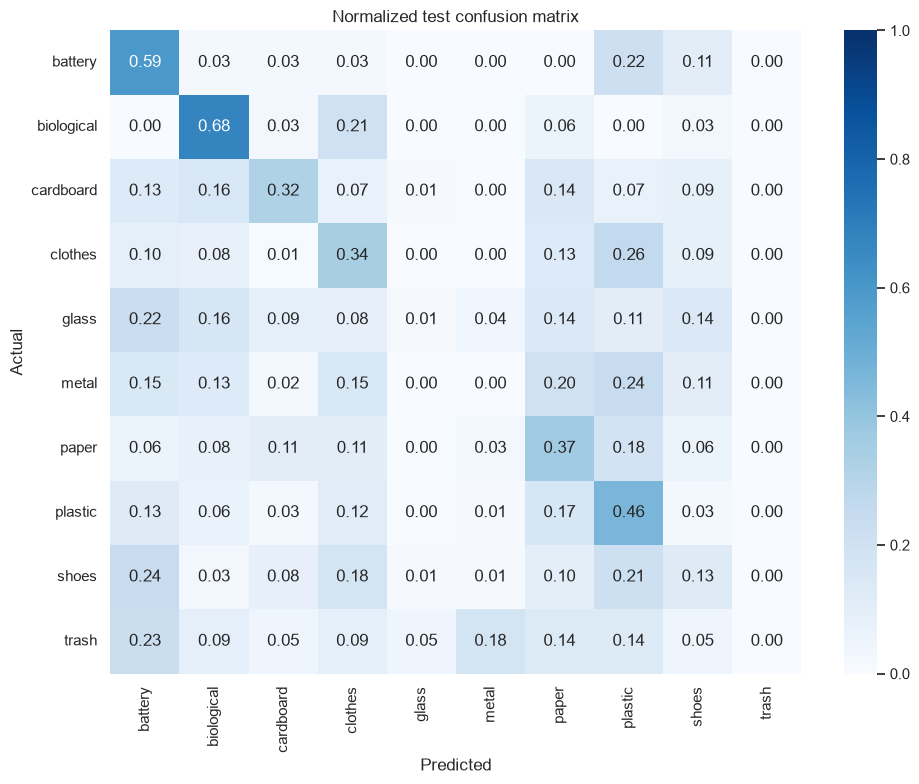

In [13]:
matrix = confusion_matrix(
    predictions_df["target"], predictions_df["prediction"], labels=class_names, normalize="true"
)
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
)
plt.title("Normalized test confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Highest-confidence mistakes

Confident mistakes are useful for spotting ambiguous labels and background bias.

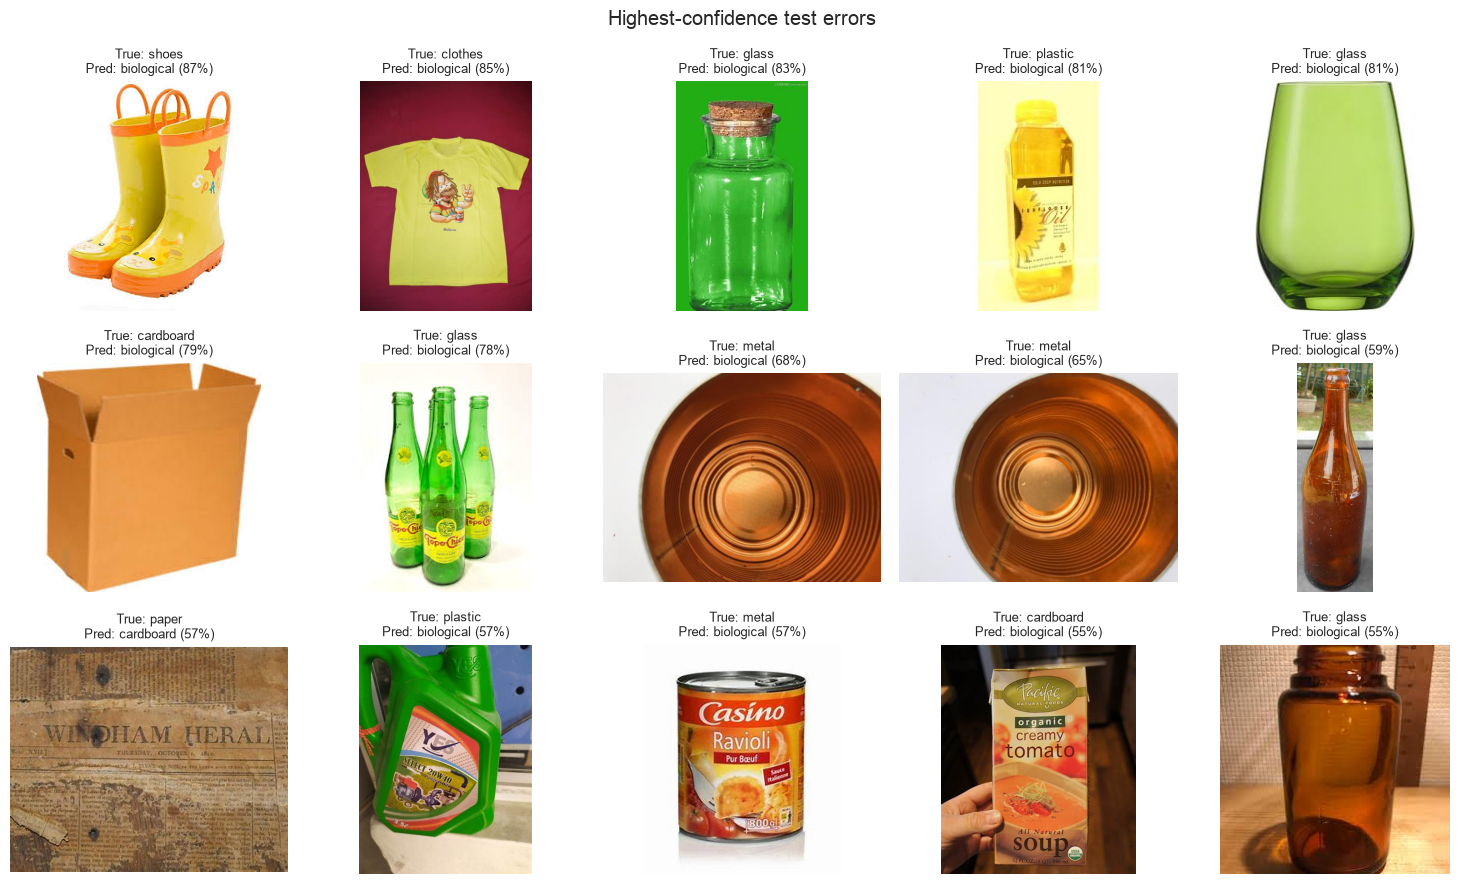

In [14]:
mistakes_df = predictions_df.loc[~predictions_df["correct"]].nlargest(15, "confidence")
if mistakes_df.empty:
    print("No mistakes in this evaluation sample.")
else:
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    for axis, (_, row) in zip(axes.flat, mistakes_df.iterrows()):
        with Image.open(row["path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"True: {row['target']}\nPred: {row['prediction']} ({row['confidence']:.0%})",
            fontsize=9,
        )
        axis.axis("off")
    for axis in axes.flat[len(mistakes_df):]:
        axis.axis("off")
    plt.suptitle("Highest-confidence test errors")
    plt.tight_layout()
    plt.show()

## Takeaways

- The resized copies are excluded, and exact duplicates are removed before splitting.
- Stratification keeps minority classes represented in each split.
- Macro-F1 is more informative than accuracy for this class distribution.
- Quick mode checks the pipeline on a subset. Model comparisons should use the full
  training set and the same saved split manifest.
- Checkpoints include the class order and input size needed for inference.